In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath"
from src.driftXpress import *
from src.eval import *
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

C:\Users\mateo\Desktop\polymath
Using: cuda


In [8]:
checkpoint = torch.load(
    "algorithm1_checkpoint.pt",
    map_location=device,
    weights_only=False,
)

f_trained = f(
    input_dim=784,
    latent_dim=32,
    num_classes=6,
).to(device)

f_trained.load_state_dict(checkpoint["model_state_dict"])
f_trained.eval()

losses = checkpoint["losses"]
recon_losses = checkpoint["recon_losses"]
kl_losses = checkpoint["kl_losses"]
drift_losses = checkpoint["drift_losses"]
var_losses = checkpoint["var_losses"]
covar_losses = checkpoint["covar_losses"]
average_V = checkpoint["average_V"]
evolution = checkpoint["evolution"]

In [5]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [6]:
class f(nn.Module):
    def __init__(
        self,
        input_dim=784,
        latent_dim=64,
        num_classes=6,
        label_dim=16,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_dim = label_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.LeakyReLU(0.2),
            nn.Linear(192, 96),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96),
            nn.LeakyReLU(0.2),
            nn.Linear(96, 192),
            nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim),
            nn.Sigmoid(),
        )

        self.label_embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48),
            nn.SiLU(),
            nn.Linear(48, 48),
            nn.SiLU(),
            nn.Linear(48, 48),
            nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        label_features = self.label_embedding(labels.long())
        generator_input = torch.cat([noise, label_features], dim=1)
        generated_latent = self.generator(generator_input)
        generated_final = self.decode(generated_latent)
        return generated_latent, generated_final

In [101]:
model = f()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 369664
Trainable parameters: 369664


In [46]:
def build_conditional_drift_cache(
    model,
    data_loader,
    num_classes,
    num_landmarks,
    T,
):
    """Build one fixed-reference attraction cache for each digit."""
    model.eval()
    reference_latents = {
        digit: []
        for digit in range(num_classes)
    }

    with torch.no_grad():
        for images, labels in data_loader:
            y_pos = images.to(device, non_blocking=True).flatten(start_dim=1)
            _, _, y_pos_latent = model.get_latent(y_pos)

            for digit in range(num_classes):
                mask = labels.to(device) == digit
                if mask.any():
                    reference_latents[digit].append(
                        y_pos_latent[mask].detach()
                    )

    drift_cache = {}
    for digit in range(num_classes):
        if not reference_latents[digit]:
            raise ValueError(f"No reference samples found for digit {digit}.")

        support = torch.cat(reference_latents[digit], dim=0)
        landmarks = select_landmarks(support, num_landmarks)
        K_uu_inv_sqrt = build_nystrom_cache(landmarks, T)
        Ap, bp = pre_compute_summaries(
            support,
            landmarks,
            K_uu_inv_sqrt,
            T,
        )
        drift_cache[digit] = (
            landmarks,
            K_uu_inv_sqrt,
            Ap,
            bp,
        )

    return drift_cache


def conditional_drift_loss(generated, labels, drift_cache, T):
    """Apply the drift field belonging to each generated digit label."""
    batch_size = generated.shape[0]
    total_loss = generated.new_zeros(())
    field = torch.zeros_like(generated)

    for digit_tensor in torch.unique(labels):
        digit = int(digit_tensor.item())
        mask = labels == digit
        landmarks, K_uu_inv_sqrt, Ap, bp = drift_cache[digit]

        digit_loss, digit_field = drift_loss(
            generated[mask],
            landmarks,
            K_uu_inv_sqrt,
            Ap,
            bp,
            T,
        )

        weight = mask.float().sum() / batch_size
        total_loss = total_loss + weight * digit_loss
        field[mask] = digit_field

    return total_loss, field


def training_loop(
    num_epochs, T, num_landmarks,
    lambda_kl, lambda_drift, lambda_var, lambda_cov,
    batch_size=1000, lr=1e-3,
):
    model = f(
        input_dim=784,
        latent_dim=LATENT_DIM,
        num_classes=NUM_CLASSES,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    evolution = []
    snapshot_epochs = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshot_epochs.add(num_epochs)

    print("Conditional training started")
    start_time = time.perf_counter()
    cache_start = time.perf_counter()
    print("Building fixed conditional attraction caches...")
    drift_cache = build_conditional_drift_cache(
        model,
        train_loader,
        NUM_CLASSES,
        num_landmarks,
        T,
    )
    print(f"Fixed attraction caches built in {(time.perf_counter() - cache_start) / 60:.2f} minutes")

    for epoch in range(num_epochs + 1):
        model.train()
        epoch_items = {
            key: 0.0
            for key in ("total", "recon", "kl", "drift", "var", "covar", "V")
        }
        last_pos = None
        last_neg = None

        for images, labels in train_loader:
            y_pos = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(
                y_pos.shape[0],
                model.latent_dim,
                device=device,
            )

            mu, logvar, y_pos_latent = model.get_latent(y_pos)
            y_pos_recon = model.decode(y_pos_latent)
            y_neg_latent, y_neg_recon = model.generate(noise, labels)

            L_drift, V = conditional_drift_loss(
                y_neg_latent,
                labels,
                drift_cache,
                T,
            )
            L_recon = recon_loss(y_pos_recon, y_pos)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(y_pos_latent) + variance_loss(y_neg_latent)
            L_cov = covariance_loss(y_pos_latent) + covariance_loss(y_neg_latent)
            lambda_drift_t = lambda_drift* min(1.0, 1.0 + 3.0 * max(0, 1 - epoch/30))  # ~4x boost in first 30 epochs, decaying to 1x
            loss = (
                L_recon
                + lambda_kl * L_kl
                + lambda_drift_t * L_drift
                + lambda_var * L_var
                + lambda_cov * L_cov
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at epoch {epoch}: {loss.item()}"
                )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_items["total"] += loss.item()
            epoch_items["recon"] += L_recon.item()
            epoch_items["kl"] += L_kl.item()
            epoch_items["drift"] += L_drift.item()
            epoch_items["var"] += L_var.item()
            epoch_items["covar"] += L_cov.item()
            epoch_items["V"] += V.norm(dim=1).mean().item()
            last_pos = y_pos_latent.detach()
            last_neg = y_neg_latent.detach()

        num_batches = len(train_loader)
        for key in epoch_items:
            epoch_items[key] /= num_batches

        train_losses.append(epoch_items["total"])
        recon_losses.append(epoch_items["recon"])
        kl_losses.append(epoch_items["kl"])
        drift_losses.append(epoch_items["drift"])
        var_losses.append(epoch_items["var"])
        covar_losses.append(epoch_items["covar"])
        average_V.append(epoch_items["V"])

        if epoch in snapshot_epochs:
            evolution.append({
                "epoch": epoch,
                "pos": last_pos.cpu().numpy(),
                "neg": last_neg.cpu().numpy(),
            })

        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- Epoch {epoch} --------")
            print(f"total={epoch_items['total']:.6f}")
            print(f"recon={epoch_items['recon']:.6f}")
            print(f"kl={epoch_items['kl']:.6f}    scaled={lambda_kl * epoch_items['kl']:.6f}")
            print(f"drift={epoch_items['drift']:.6f}    scaled={lambda_drift_t * epoch_items['drift']:.6f}")
            print(f"var={epoch_items['var']:.6f}    scaled={lambda_var * epoch_items['var']:.6f}")
            print(f"covar={epoch_items['covar']:.6f}    scaled={lambda_cov * epoch_items['covar']:.6f}")
            print("distances", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print(f"average |V|={epoch_items['V']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    elapsed = (time.perf_counter() - start_time) / 60
    print(f"Finished. Training took {elapsed:.2f} minutes")
    return (
        model, train_losses, recon_losses, kl_losses,
        drift_losses, var_losses, covar_losses, average_V, evolution,
    )


In [102]:
NUM_CLASSES = 6
LATENT_DIM = 32
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(
    NUM_EPOCHS,
    TEMPERATURE,
    NUM_LANDMARKS,
    LAMBDA_KL,
    LAMBDA_DRIFT,
    LAMBDA_VAR,
    LAMBDA_COV,
    batch_size=BATCH_SIZE,
    lr=1e-3,
)

Conditional training started
Building fixed conditional attraction caches...
Fixed attraction caches built in 0.11 minutes
-------- Epoch 0 --------
total=0.361539
recon=0.094731
kl=2.763942    scaled=0.000028
drift=0.001666    scaled=0.049980
var=1.891746    scaled=0.189175
covar=0.092087    scaled=0.027626
distances 8.40371036529541
average |V|=0.173331
latent std positive=1.080539
latent std negative=0.025405
-------- Epoch 1 --------
total=0.284860
recon=0.068626
kl=1.186523    scaled=0.000012
drift=0.000080    scaled=0.002386
var=1.870761    scaled=0.187076
covar=0.089200    scaled=0.026760
distances 8.444893836975098
average |V|=0.048312
latent std positive=1.084522
latent std negative=0.061673
-------- Epoch 2 --------
total=0.281769
recon=0.067837
kl=1.011219    scaled=0.000010
drift=0.000112    scaled=0.003359
var=1.837575    scaled=0.183758
covar=0.089350    scaled=0.026805
distances 8.183511734008789
average |V|=0.057075
latent std positive=1.088942
latent std negative=0.092

In [116]:
torch.save(
    {
        "model_state_dict": f_trained.state_dict(),
        "losses": losses,
        "recon_losses": recon_losses,
        "kl_losses": kl_losses,
        "drift_losses": drift_losses,
        "var_losses": var_losses,
        "covar_losses": covar_losses,
        "average_V": average_V,
        "evolution": evolution,
    },
    "algorithm1_checkpoint.pt",
)

In [103]:
f_trained.train()

images, labels = next(iter(train_loader))
y_pos = images.to(device).flatten(start_dim=1)
labels = labels.to(device)

noise = torch.randn(
    y_pos.shape[0],
    f_trained.latent_dim,
    device=device,
)

mu, logvar, y_pos_latent = f_trained.get_latent(y_pos)
y_neg_latent, y_neg_recon = f_trained.generate(noise, labels)

drift_cache = build_conditional_drift_cache(
    f_trained,
    train_loader,
    NUM_CLASSES,
    NUM_LANDMARKS,
    TEMPERATURE,
)

L_drift, V = conditional_drift_loss(
    y_neg_latent,
    labels,
    drift_cache,
    TEMPERATURE,
)

print(gradient_report(L_drift, f_trained))

{'encoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 8}, 'decoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 6}, 'generator': {'total_norm': 0.2856197664514184, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.001773219439201057, 'nonzero_parameters': 1, 'parameter_count': 1}}


In [104]:
def temp_search(y_pos, T_values, sample_size=500):
    idx = torch.randperm(len(y_pos))[:sample_size]
    sample = y_pos[idx]
    dists = torch.cdist(sample, sample)
    dists = dists[dists > 0]
    
    for T in T_values:
        logits = -dists / T
        print(f"T={T:.3f}  logits.std={logits.std().item():.3f}")

temp_search(y_pos_latent, T_values=[0.1, 0.5, 1, 2, 5, 10, 20])

T=0.100  logits.std=44.363
T=0.500  logits.std=8.873
T=1.000  logits.std=4.436
T=2.000  logits.std=2.218
T=5.000  logits.std=0.887
T=10.000  logits.std=0.444
T=20.000  logits.std=0.222


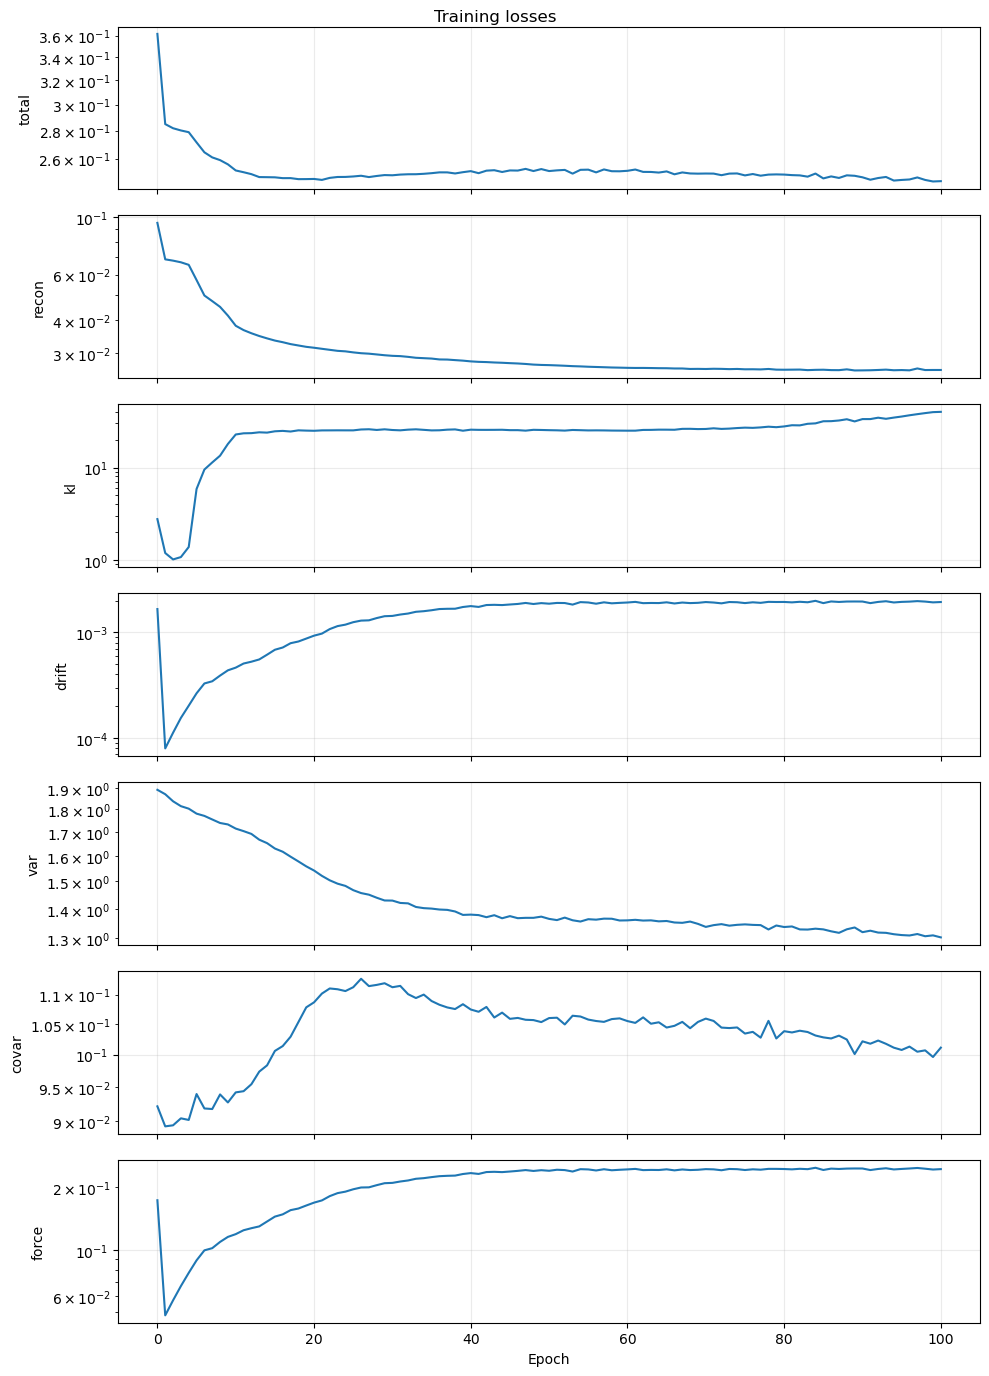

In [105]:
history = {
    "total": losses,
    "recon": recon_losses,
    "kl": kl_losses,
    "drift": drift_losses,
    "var": var_losses,
    "covar": covar_losses,
    "force": average_V,
}

fig, axes = plot_loss_history(history)
plt.show()

In [9]:
f_trained.eval()

real_latents = []
real_class_labels = []

with torch.no_grad():
    for images, class_labels in test_loader:
        images = images.to(device).flatten(start_dim=1)
        mu, logvar, z = f_trained.get_latent(images)
        real_latents.append(mu.cpu())
        real_class_labels.append(class_labels)

real_latents = torch.cat(real_latents).numpy()
real_class_labels = torch.cat(real_class_labels).numpy()
real_labels = CLASS_TO_DIGIT[real_class_labels]

n_samples = real_latents.shape[0]

with torch.no_grad():
    noise = torch.randn(
        n_samples,
        f_trained.latent_dim,
        device=device,
    )
    generated_class_labels_tensor = torch.randint(
        0,
        f_trained.num_classes,
        (n_samples,),
        device=device,
    )
    generated_latents, generated_images = f_trained.generate(
        noise,
        generated_class_labels_tensor,
    )

generated_latents = generated_latents.cpu().numpy()
generated_images = generated_images.cpu().numpy()
generated_class_labels = generated_class_labels_tensor.cpu().numpy()
generated_labels = CLASS_TO_DIGIT[generated_class_labels]


In [11]:
real_pixels = (
    test_data.data.float()
    .reshape(len(test_data), -1)
    .numpy() / 255.0
)
NUM_CLASSES = 6
generated_pixels = (
    generated_images.detach().cpu().numpy()
    if hasattr(generated_images, "detach")
    else np.asarray(generated_images)
)
generated_pixels = generated_pixels.reshape(len(generated_pixels), -1)

metrics = evaluate_generation(
    real_features=real_pixels,
    generated_features=generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    mmd_max_samples=128,
)

for name, value in metrics.items():
    print(f"{name}: {value:.6f}")

print("\nPer-digit pixel metrics:")
for class_id, digit in enumerate(SELECTED_DIGITS):
    real_mask = real_class_labels == class_id
    generated_mask = generated_class_labels == class_id

    if generated_mask.any():
        digit_metrics = evaluate_generation(
            real_features=real_pixels[real_mask],
            generated_features=generated_pixels[generated_mask],
            mmd_max_samples=128,
        )
        print(f"digit {digit}: {digit_metrics}")

sliced_wasserstein: 0.155204
mmd_rbf: 0.146003
fid: 32.192295
class_coverage: 1.000000
class_entropy: 0.999801

Per-digit pixel metrics:
digit 0: {'sliced_wasserstein': 0.20118187922224853, 'mmd_rbf': 0.25062549190758654, 'fid': 58.28217108917318}
digit 8: {'sliced_wasserstein': 0.18127642686297338, 'mmd_rbf': 0.2705014586173009, 'fid': 51.83914641661082}
digit 2: {'sliced_wasserstein': 0.17934593300512366, 'mmd_rbf': 0.19558248072477769, 'fid': 46.66355267404394}
digit 4: {'sliced_wasserstein': 0.1405341195338588, 'mmd_rbf': 0.22413411732758193, 'fid': 39.79237918176575}
digit 7: {'sliced_wasserstein': 0.1377444851951807, 'mmd_rbf': 0.20160265550655065, 'fid': 33.549925587790135}
digit 9: {'sliced_wasserstein': 0.15203834266058647, 'mmd_rbf': 0.21580316875143546, 'fid': 40.217157354847146}


In [108]:
print("Real latent mean:",
      real_latents.mean(axis=0).mean())

print("Generated latent mean:",
      generated_latents.mean(axis=0).mean())

print("Real latent std:",
      real_latents.std(axis=0).mean())

print("Generated latent std:",
      generated_latents.std(axis=0).mean())

Real latent mean: 0.0032471945
Generated latent mean: 0.011456685
Real latent std: 0.24103788
Generated latent std: 0.5596269


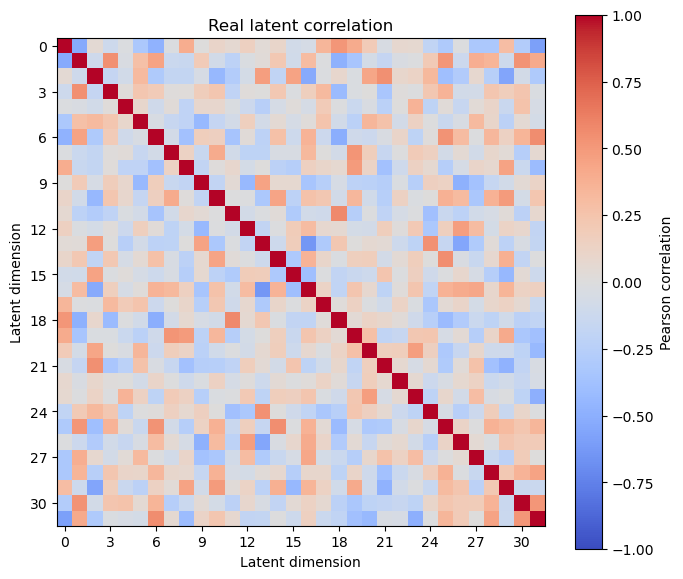

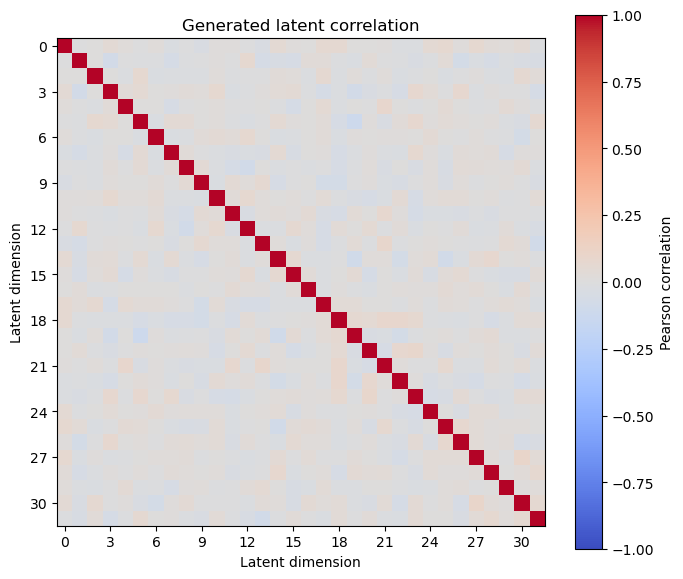

In [109]:
fig, ax, real_correlation = plot_latent_correlation(
    latents=real_latents,
    annotate=False,
)
ax.set_title("Real latent correlation")
plt.show()

fig, ax, generated_correlation = plot_latent_correlation(
    latents=generated_latents,
    annotate=False,
)
ax.set_title("Generated latent correlation")
plt.show()

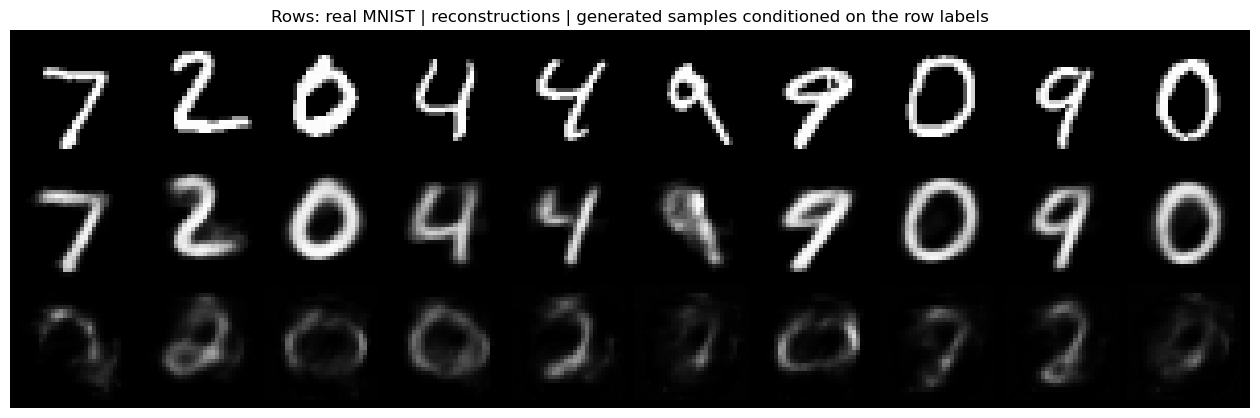

In [110]:
@torch.no_grad()
def show_mnist_results(model, samples=10):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:samples].to(device).flatten(start_dim=1)
    labels = labels[:samples].to(device)

    _, _, z_pos = model.get_latent(images)
    reconstructions = model.decode(z_pos).view(-1, 1, 28, 28).cpu()

    noise = torch.randn(samples, model.latent_dim, device=device)
    _, generated = model.generate(noise, labels)
    generated = generated.view(-1, 1, 28, 28).cpu()

    comparison = torch.cat([
        images.view(-1, 1, 28, 28).cpu(),
        reconstructions,
        generated,
    ])
    grid = utils.make_grid(comparison, nrow=samples, padding=2)
    plt.figure(figsize=(16, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
        "Rows: real MNIST | reconstructions | generated samples "
        "conditioned on the row labels"
    )
    plt.show()


show_mnist_results(f_trained)

In [12]:
import sys
import importlib
import numba

numba_core = importlib.import_module("numba.core")

# Repair the missing module attribute if necessary.
if not hasattr(numba, "core"):
    numba.core = numba_core

print(sys.executable)
print(numba.__version__)
print(numba.core)

C:\Users\mateo\anaconda3\python.exe
0.62.1
<module 'numba.core' from 'C:\\Users\\mateo\\anaconda3\\Lib\\site-packages\\numba\\core\\__init__.py'>


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


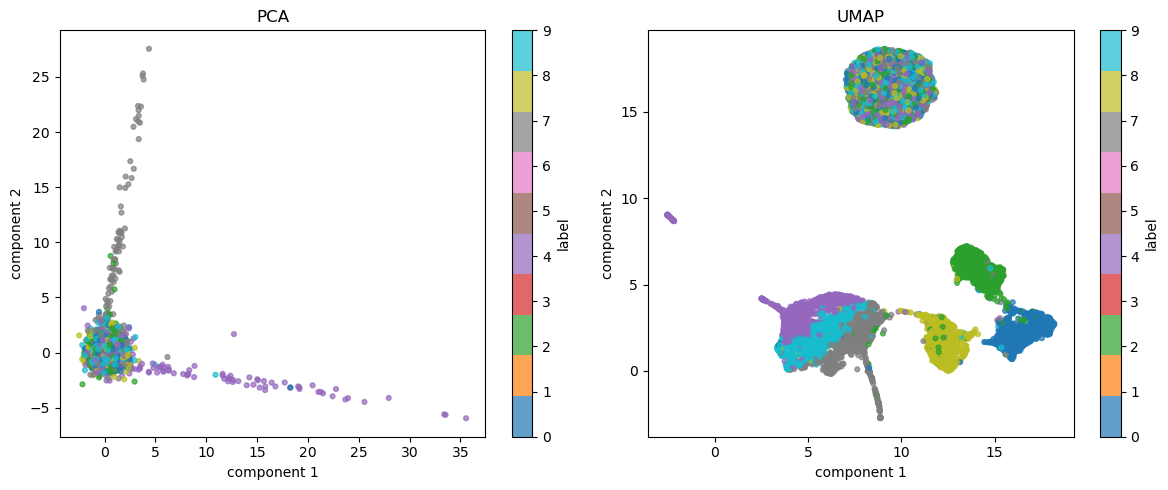

In [13]:
fig, axes = plot_latent_projections(
    latents=np.concatenate([real_latents, generated_latents]),
    labels=np.concatenate([real_labels, generated_labels]),
    methods=("pca", "umap"),
)

plt.show()

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


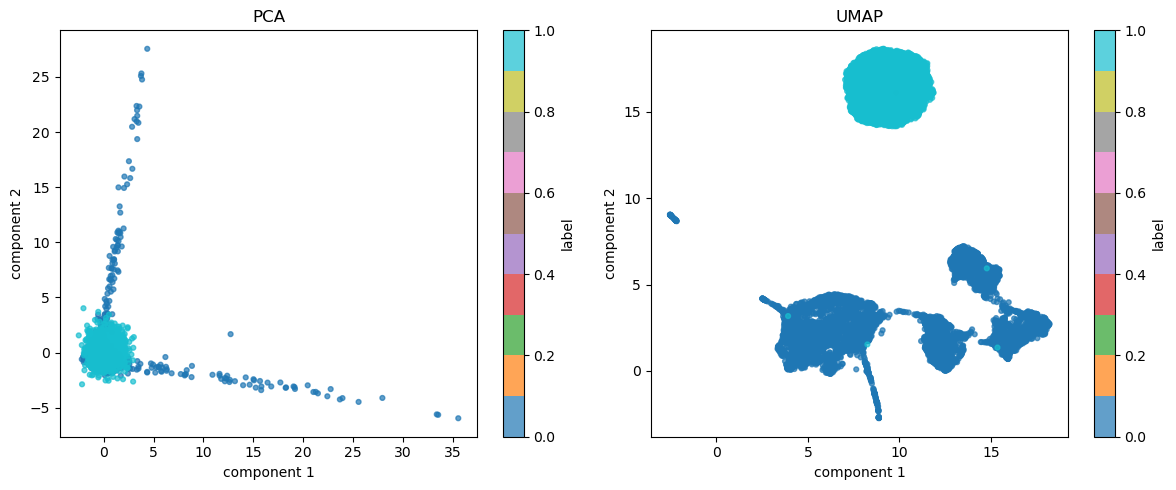

In [14]:
fig, axes = plot_latent_projections(
    latents=np.concatenate([real_latents, generated_latents]),
    labels=np.concatenate([
        np.zeros(len(real_latents)),
        np.ones(len(generated_latents)),
    ]),
    methods=("pca", "umap"),
)

plt.show()

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


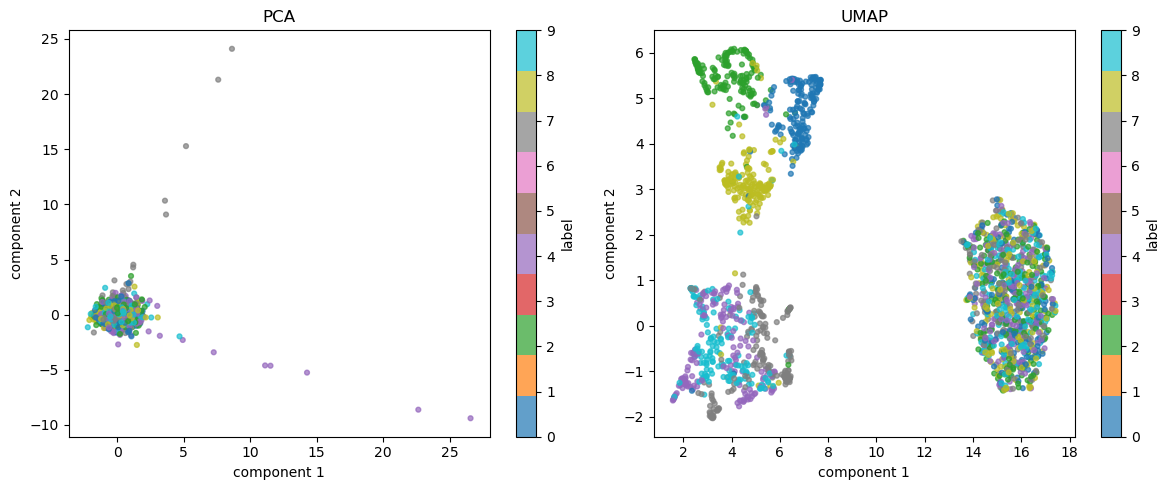

In [15]:
rng = np.random.default_rng(0)
n_per_source = min(1000, len(real_latents), len(generated_latents))

real_idx = rng.choice(len(real_latents), n_per_source, replace=False)
generated_idx = rng.choice(
    len(generated_latents),
    n_per_source,
    replace=False,
)

plot_latents = np.concatenate([
    real_latents[real_idx],
    generated_latents[generated_idx],
])

plot_labels = np.concatenate([
    real_labels[real_idx],
    generated_labels[generated_idx],
])

fig, axes = plot_latent_projections(
    latents=plot_latents,
    labels=plot_labels,
    methods=("pca", "umap"),
)

plt.show()